In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
file_path = r'C:\Users\DELL\Desktop\guvi\Project4\data\india_housing_prices.csv'

In [9]:
df = pd.read_csv(file_path)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [11]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [12]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [13]:
# 3. Check for Null Values (Data Handling) 
print(df.isnull().sum())

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64


In [14]:
# Remove identical rows
df = df.drop_duplicates()

In [15]:
# 1. Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [16]:
print(df.columns.tolist())

['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


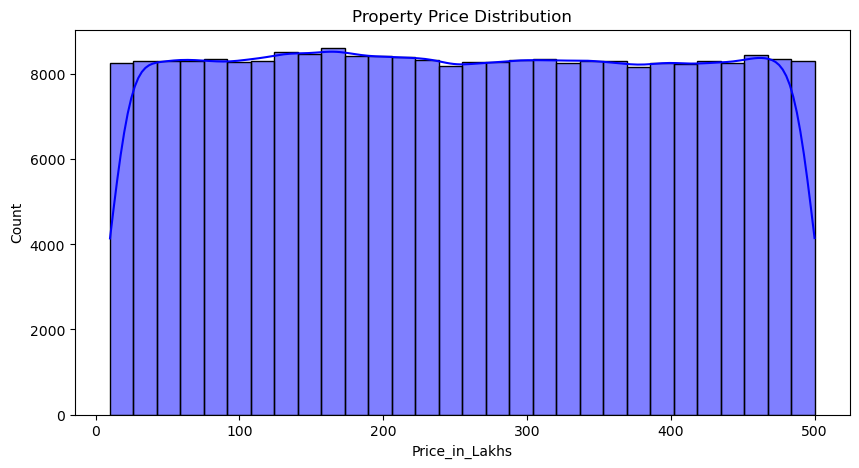

In [17]:
# Question 1. Distribution of Property Prices
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_in_Lakhs'].dropna(), bins=30, kde=True, color='blue')
plt.title('Property Price Distribution')
plt.show()

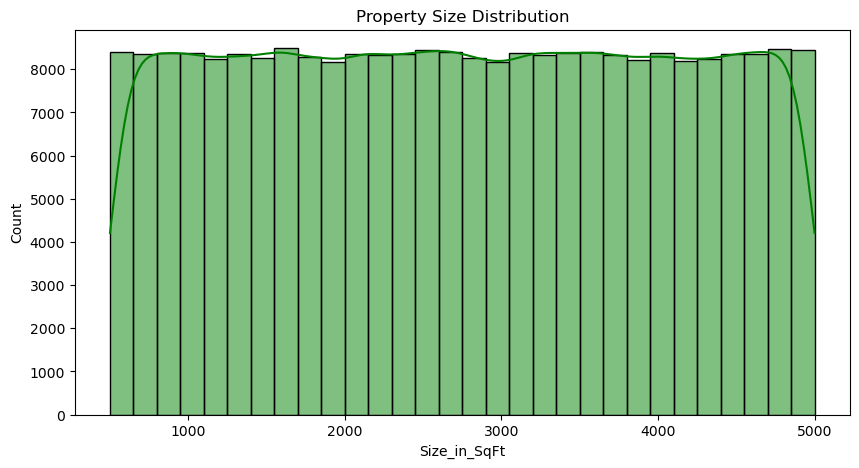

In [18]:
# Question  2. Distribution of Property Sizes 
plt.figure(figsize=(10, 5))
sns.histplot(df['Size_in_SqFt'], bins=30, kde=True, color='green')
plt.title('Property Size Distribution')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\2648010685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df, palette='Set2')


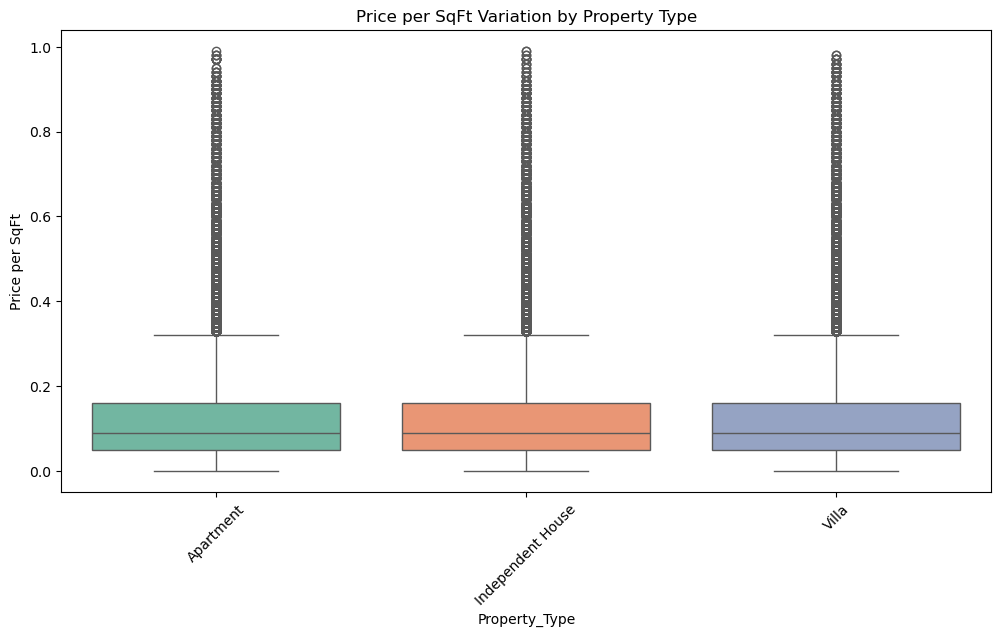

In [19]:
# Question 3. How does the price per sq ft vary by property type? 
plt.figure(figsize=(12, 6))
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df, palette='Set2')
plt.title('Price per SqFt Variation by Property Type')
plt.xticks(rotation=45)
plt.ylabel('Price per SqFt')
plt.show()

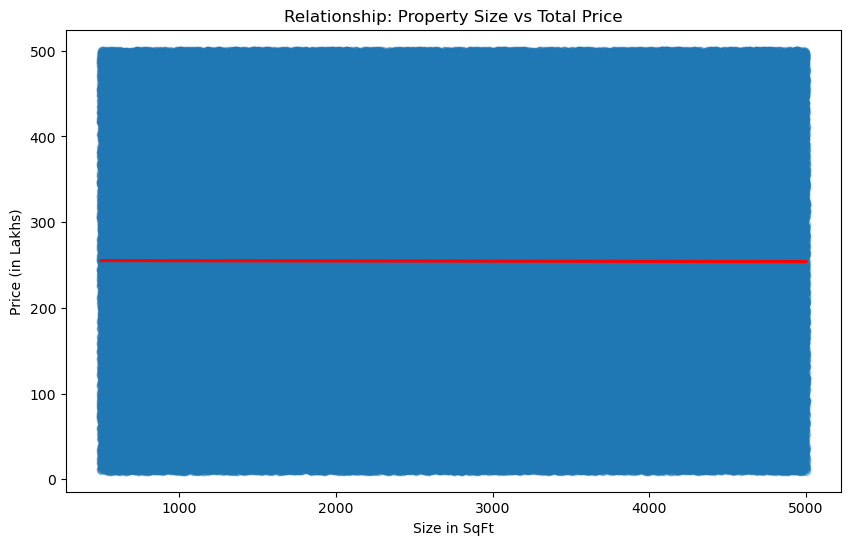

In [20]:
# Question 4. Is there a relationship between property size and price? (Question 4)
plt.figure(figsize=(10, 6))
sns.regplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship: Property Size vs Total Price')
plt.xlabel('Size in SqFt')
plt.ylabel('Price (in Lakhs)')
plt.show()

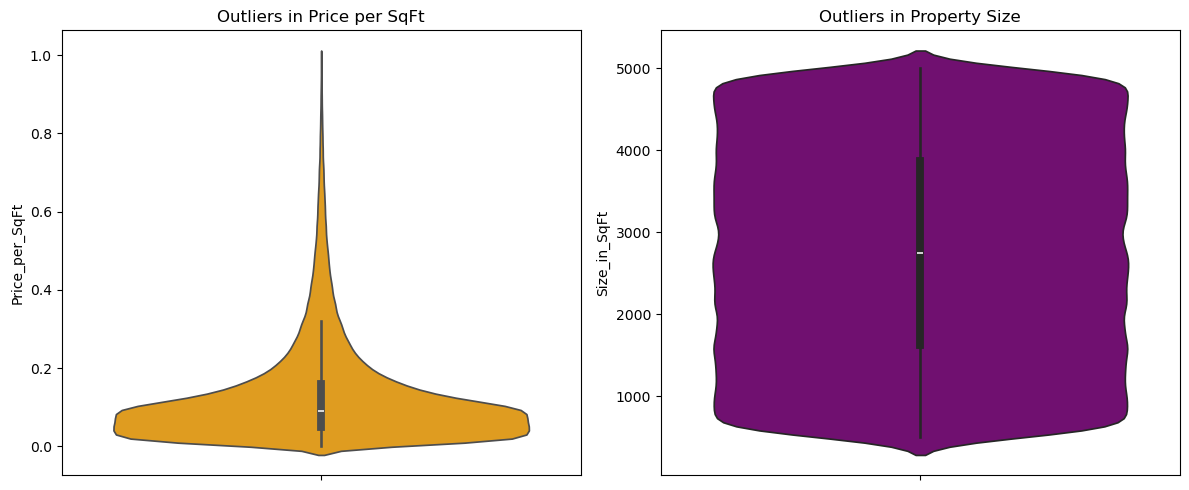

In [21]:
# Question 5. Are there any outliers in price per sq ft or property size?
plt.figure(figsize=(12, 5))

# Subplot for Price per SqFt outliers
plt.subplot(1, 2, 1)
sns.violinplot(y=df['Price_per_SqFt'], color='orange')
plt.title('Outliers in Price per SqFt')

# Subplot for Size outliers
plt.subplot(1, 2, 2)
sns.violinplot(y=df['Size_in_SqFt'], color='purple')
plt.title('Outliers in Property Size')

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\1762178904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_price.index, y=state_price.values, palette='viridis')


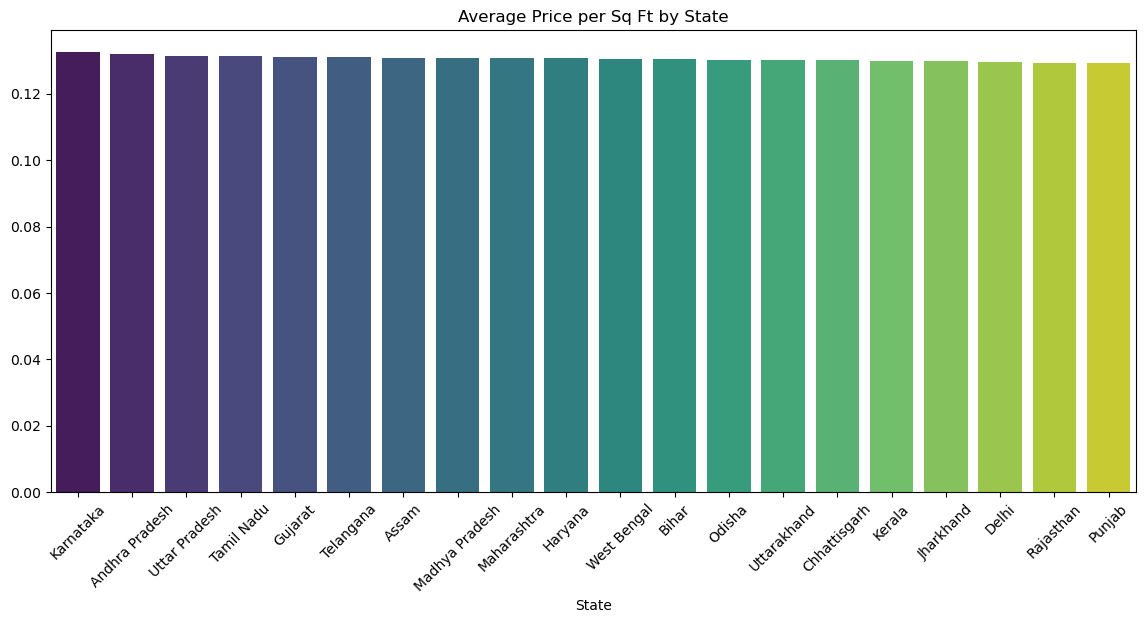

In [22]:
# 6. Average Price per Sq Ft by State (Question 6)
plt.figure(figsize=(14, 6))
state_price = df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False)
sns.barplot(x=state_price.index, y=state_price.values, palette='viridis')
plt.title('Average Price per Sq Ft by State')
plt.xticks(rotation=45)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\684568525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_price.index, y=city_price.values, palette='magma')


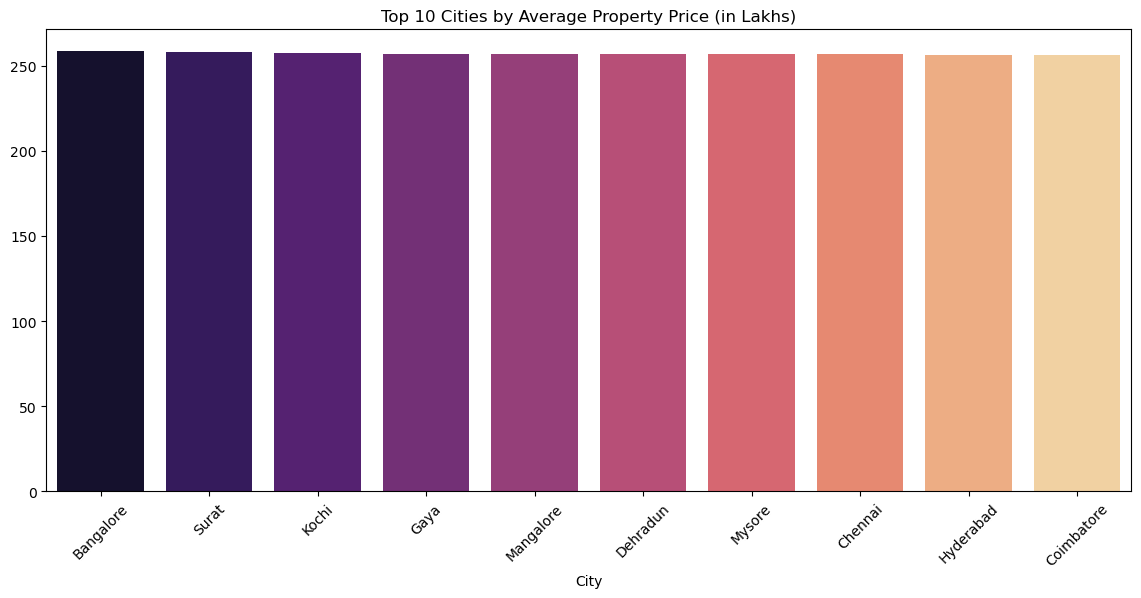

In [23]:
# 7. Average Property Price by City (Question 7)
plt.figure(figsize=(14, 6))
city_price = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=city_price.index, y=city_price.values, palette='magma')
plt.title('Top 10 Cities by Average Property Price (in Lakhs)')
plt.xticks(rotation=45)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\2241573566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=locality_age.index, y=locality_age.values, palette='coolwarm')


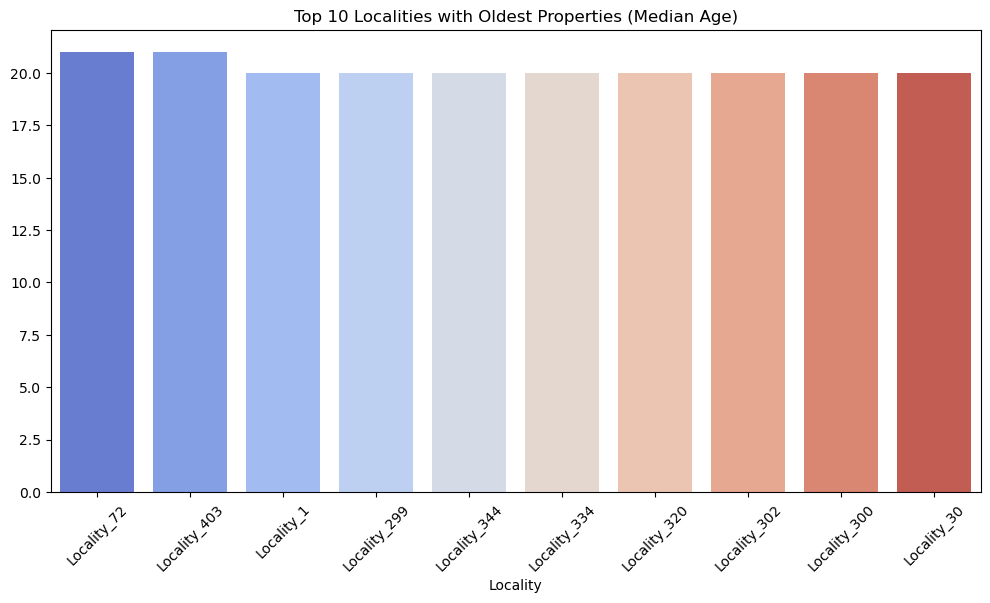

In [24]:
# we already calculate  Age_of_Property 
plt.figure(figsize=(12, 6))
locality_age = df.groupby('Locality')['Age_of_Property'].median().sort_values(ascending=False).head(10)
sns.barplot(x=locality_age.index, y=locality_age.values, palette='coolwarm')
plt.title('Top 10 Localities with Oldest Properties (Median Age)')
plt.xticks(rotation=45)
plt.show()

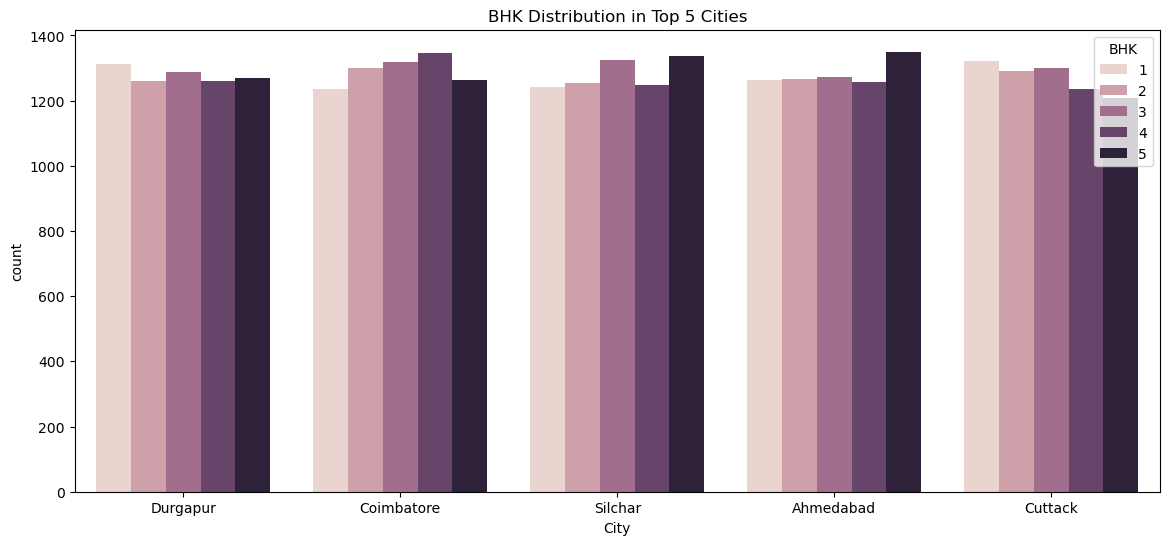

In [25]:
# 9. BHK Distribution across Cities (Question 9)
plt.figure(figsize=(14, 6))
sns.countplot(x='City', hue='BHK', data=df[df['City'].isin(df['City'].value_counts().head(5).index)])
plt.title('BHK Distribution in Top 5 Cities')
plt.show()

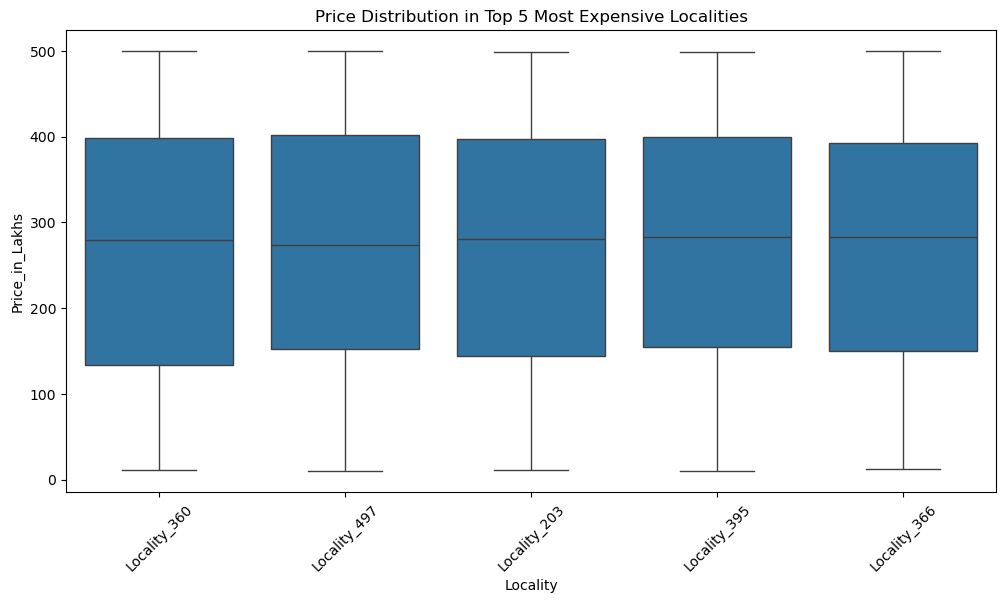

In [26]:
# 10. Price Trends for top 5 most expensive localities 
top_5_localities = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5).index
df_top_localities = df[df['Locality'].isin(top_5_localities)]
plt.figure(figsize=(12, 6))
sns.boxplot(x='Locality', y='Price_in_Lakhs', data=df_top_localities)
plt.title('Price Distribution in Top 5 Most Expensive Localities')
plt.xticks(rotation=45)
plt.show()

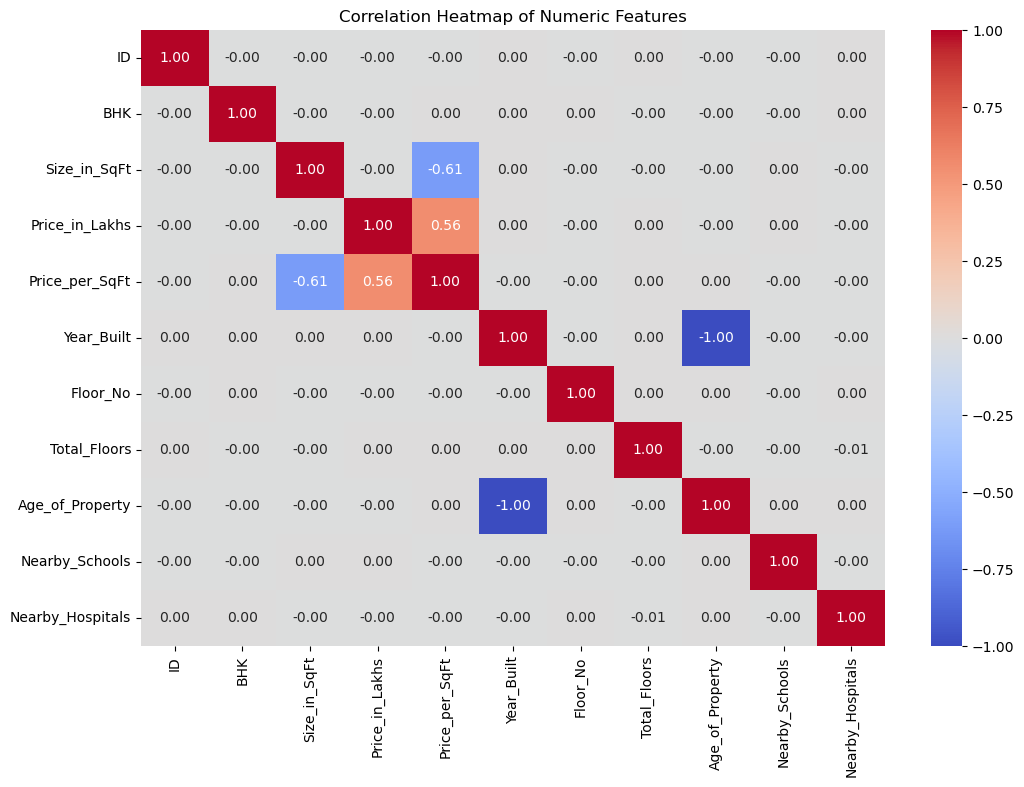

In [27]:
# 11. Correlation Heatmap for Numeric Features (Question 11)
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

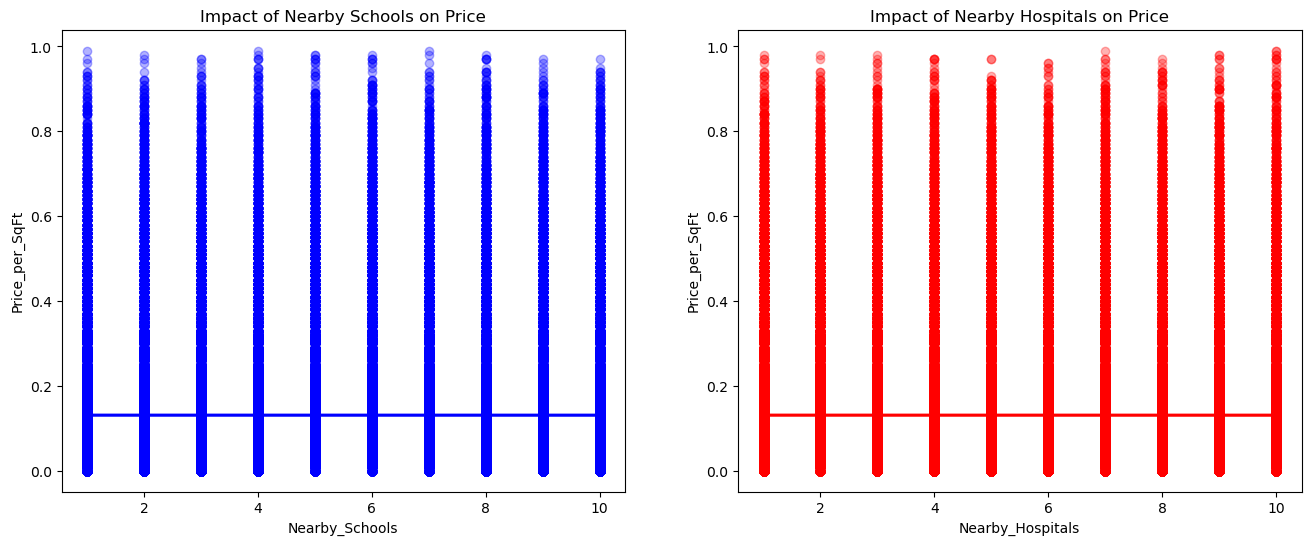

In [28]:
# 12 & 13. Relationship of Nearby Schools & Hospitals with Price (Questions 12 & 13)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='Nearby_Schools', y='Price_per_SqFt', data=df, ax=ax[0], color='blue', scatter_kws={'alpha':0.3})
ax[0].set_title('Impact of Nearby Schools on Price')

sns.regplot(x='Nearby_Hospitals', y='Price_per_SqFt', data=df, ax=ax[1], color='red', scatter_kws={'alpha':0.3})
ax[1].set_title('Impact of Nearby Hospitals on Price')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\3686109820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Furnished_Status', y='Price_in_Lakhs', data=df, palette='Set3')


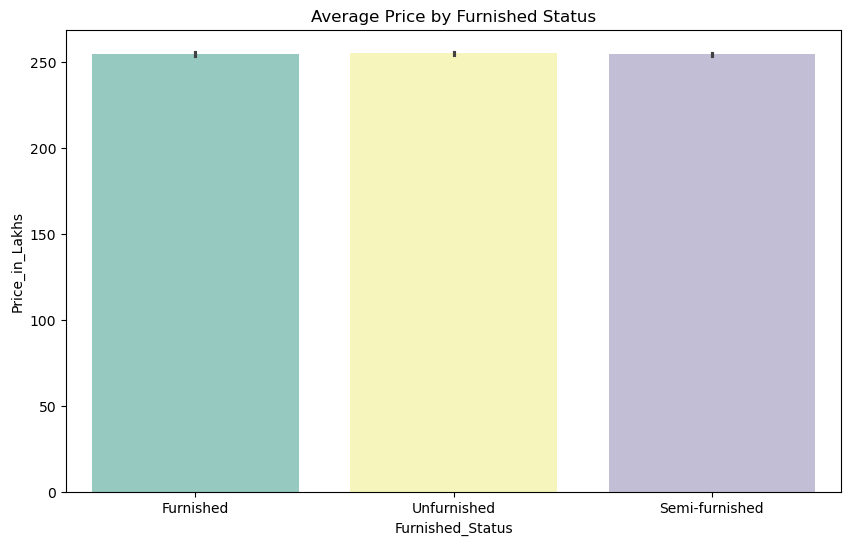

In [29]:
# 14. Price Variation by Furnished Status (Question 14)
plt.figure(figsize=(10, 6))
sns.barplot(x='Furnished_Status', y='Price_in_Lakhs', data=df, palette='Set3')
plt.title('Average Price by Furnished Status')
plt.show()

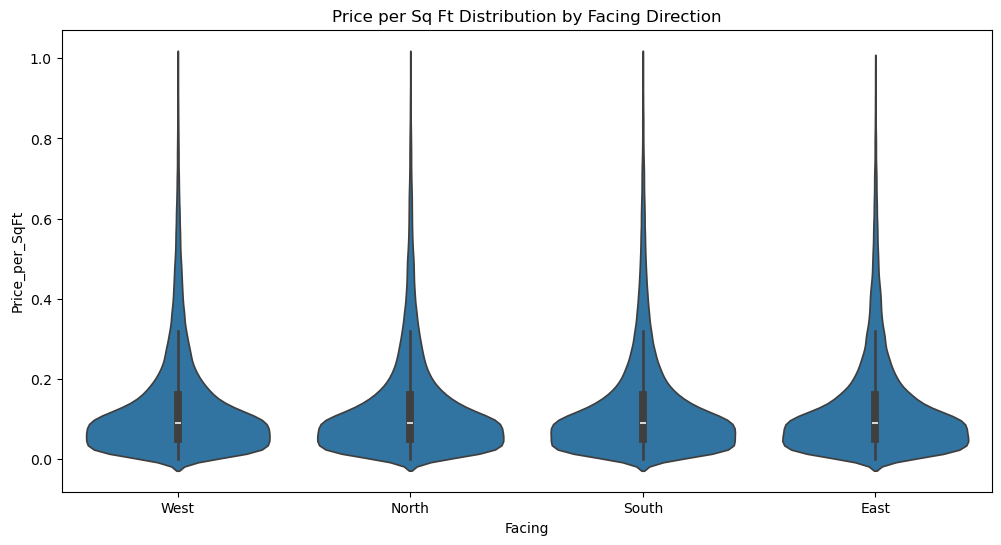

In [30]:
# 15. Price per Sq Ft by Facing Direction (Question 15)
plt.figure(figsize=(12, 6))
sns.violinplot(x='Facing', y='Price_per_SqFt', data=df)
plt.title('Price per Sq Ft Distribution by Facing Direction')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\463606474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Owner_Type', data=df, palette='pastel')


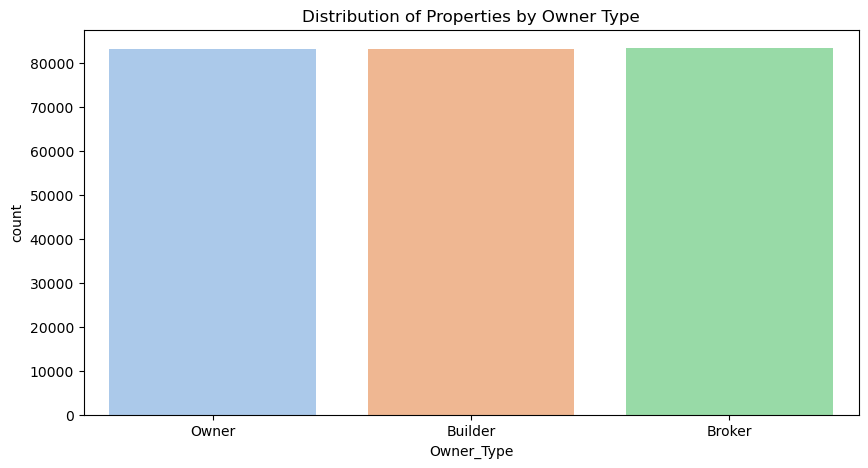

In [31]:
# 16. Count of properties by Owner Type (Question 16)
plt.figure(figsize=(10, 5))
sns.countplot(x='Owner_Type', data=df, palette='pastel')
plt.title('Distribution of Properties by Owner Type')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8720\3683318547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Availability_Status', data=df, palette='viridis')


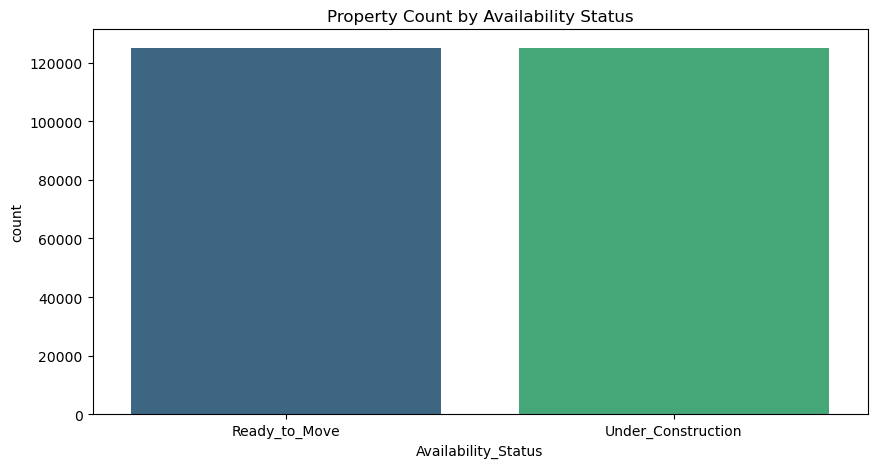

In [32]:
# 17. Availability Status Distribution (Question 17)
plt.figure(figsize=(10, 5))
sns.countplot(x='Availability_Status', data=df, palette='viridis')
plt.title('Property Count by Availability Status')
plt.show()

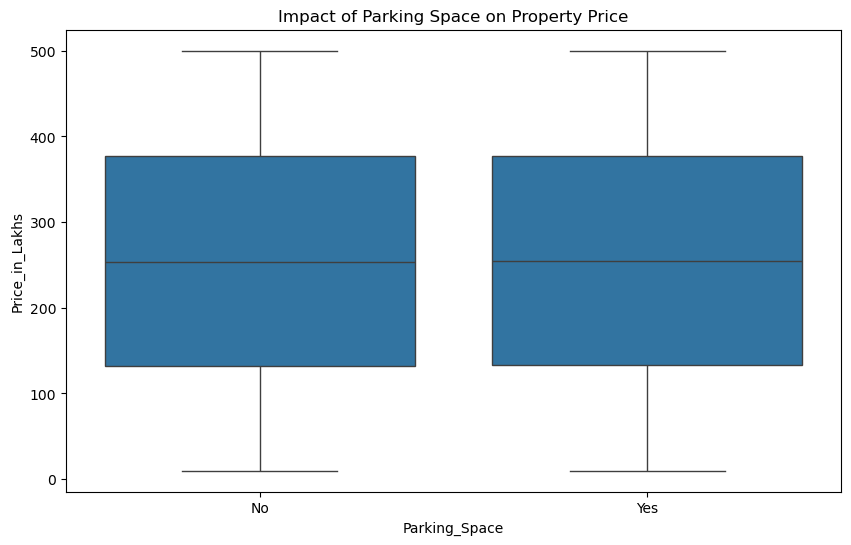

In [33]:
# 18. Does parking space affect property price? (Question 18)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Parking_Space', y='Price_in_Lakhs', data=df)
plt.title('Impact of Parking Space on Property Price')
plt.show()

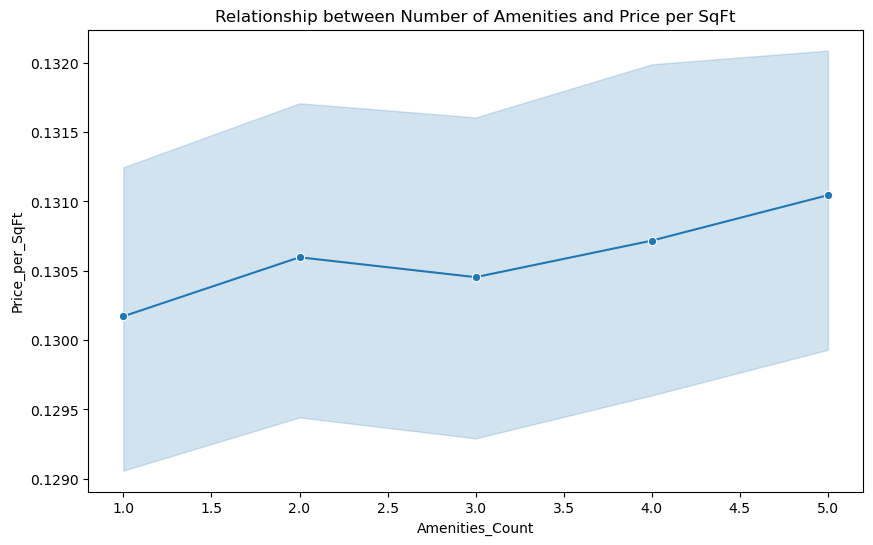

In [34]:
# 19. How do amenities affect price per sq ft? (Question 19)
df['Amenities_Count'] = df['Amenities'].apply(lambda x: len(str(x).split(',')))
plt.figure(figsize=(10, 6))
sns.lineplot(x='Amenities_Count', y='Price_per_SqFt', data=df, marker='o')
plt.title('Relationship between Number of Amenities and Price per SqFt')
plt.show()

In [35]:
# 1. Price_per_SqFt is calculate
df['Price_per_SqFt'] = (df['Price_in_Lakhs'] * 100000) / df['Size_in_SqFt']

# 2. created 'Good_Investment' Column 
city_median = df.groupby('City')['Price_per_SqFt'].transform('median')
df['Good_Investment'] = (df['Price_per_SqFt'] <= city_median).astype(int)

print("Column 'Good_Investment' successfully created!")
print(df[['City', 'Price_per_SqFt', 'Good_Investment']].head())

Column 'Good_Investment' successfully created!
       City  Price_per_SqFt  Good_Investment
0   Chennai    10332.489451                0
1      Pune     8270.727580                1
2  Ludhiana     5046.403075                1
3   Jodhpur    10955.490697                0
4    Jaipur     3792.245490                1


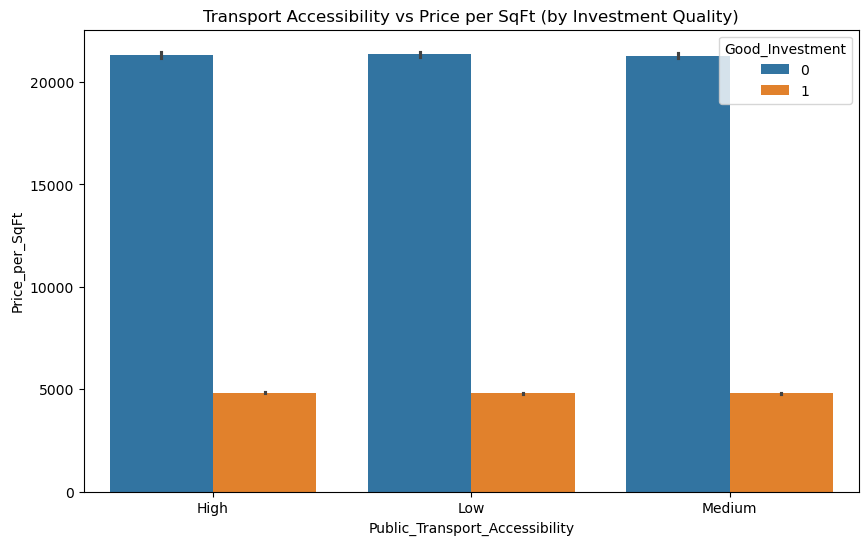

In [36]:
# 20. Public transport accessibility vs Investment Potential (Question 20)
plt.figure(figsize=(10, 6))
# Ab 'Good_Investment' column mil jayega
sns.barplot(x='Public_Transport_Accessibility', y='Price_per_SqFt', hue='Good_Investment', data=df)
plt.title('Transport Accessibility vs Price per SqFt (by Investment Quality)')
plt.show()

In [39]:
import os
os.makedirs("data", exist_ok=True)

df.to_csv("data/cleaned_data.csv", index=False)

print("File Saved Successfully!")

File Saved Successfully!
